<a href="https://colab.research.google.com/github/isil-ada/stellar-mlp-classification/blob/main/4_Scikit_learn_MLPClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 4 — Scikit-learn MLPClassifier
## Stellar Classification —  En İyi Modellerle Sklearn Uygulaması

Bu notebook, 3. notebook'ta NumPy ile sıfırdan yazılan MLP modellerini
**Scikit-learn MLPClassifier** ile aynı mimariler kullanarak tekrar uygular.

**Kullanılan mimariler** (3. notebook'taki en iyi modellerden seçildi):
| Model | Mimari | Özellik |
|-------|--------|---------|
| M1 | 14→32→3 | Temel model (1 gizli katman) |
| M4 | 14→64→32→3 | 2 gizli katman |
| M5 | 14→64→32→3 | 2 gizli katman + L2 (alpha=0.01) |
| M6 | 14→64→32→16→3 | 3 gizli katman |

**Optimizer:** Sklearn varsayılanı → `adam`

**Aktivasyon:** `tanh`


# **1. Kütüphaneler ve Veri Hazırlama**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Veri yükleme
df = pd.read_csv("/content/star_classification.csv.zip")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

In [4]:
df.head(10)

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842
5,1.237680e+18,340.995121,20.589476,23.48827,23.33776,21.32195,20.25615,19.54544,8102,301,3,110,5.658977e+18,QSO,1.424659,5026,55855,741
6,1.237679e+18,23.234926,11.418188,21.46973,21.17624,20.92829,20.60826,20.42573,7773,301,2,462,1.246262e+19,QSO,0.586455,11069,58456,113
7,1.237679e+18,5.433176,12.065186,22.24979,22.02172,20.34126,19.48794,18.84999,7773,301,2,346,6.961443e+18,GALAXY,0.477009,6183,56210,15
8,1.237661e+18,200.290475,47.199402,24.40286,22.35669,20.61032,19.46490,18.95852,3716,301,5,108,7.459285e+18,GALAXY,0.660012,6625,56386,719
9,1.237671e+18,39.149691,28.102842,21.74669,20.03493,19.17553,18.81823,18.65422,5934,301,4,122,2.751763e+18,STAR,-0.000008,2444,54082,232


In [5]:
print("\nEksik değer:")
print(df.isnull().sum())


Eksik değer:
obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64


In [6]:
print("Sınıf dağılımı:")
print(df['class'].value_counts())

Sınıf dağılımı:
class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64


In [7]:
# ID sütunlarını sil
drop_cols = ['obj_ID','run_ID','rerun_ID','cam_col','field_ID',
             'spec_obj_ID','plate','MJD','fiber_ID']
df_clean = df.drop(columns=drop_cols).copy()

In [8]:
# Özellik mühendisliği: astronomik renk indeksleri
for a, b in [('u','g'),('g','r'),('r','i'),('i','z'),('u','r')]:
    df_clean[f'{a}_{b}'] = df_clean[a] - df_clean[b]
df_clean['redshift_sq'] = df_clean['redshift'] ** 2

In [9]:
# Label encoding: GALAXY=0, QSO=1, STAR=2
le = LabelEncoder()
y_raw = le.fit_transform(df_clean['class'])

In [10]:
# Özellik matrisi
feature_cols = ['alpha','delta','u','g','r','i','z','redshift',
                'u_g','g_r','r_i','i_z','u_r','redshift_sq']
X_raw = df_clean[feature_cols].values

In [11]:
# StandardScaler (tek fit: train üzerinde)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

In [12]:
# train test val split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y_raw, test_size=0.30, random_state=42, stratify=y_raw)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=2/3, random_state=42, stratify=y_temp)

In [13]:
print(f'Train: {X_train.shape[0]}  Val: {X_val.shape[0]}  Test: {X_test.shape[0]}')
print('Sınıflar:', le.classes_)

Train: 70000  Val: 10000  Test: 20000
Sınıflar: ['GALAXY' 'QSO' 'STAR']


# **2. Model Tanımları**

Sklearn MLPClassifier'ın varsayılan optimizer'ı `adam`'dır.
Aktivasyon olarak 3. notebook ile tutarlı şekilde `tanh` kullanılır.


In [14]:
sklearn_configs = [
    {
        'name'  : 'M1: 1 gizli n_h=32',
        'model' : MLPClassifier(
            hidden_layer_sizes=(32,),
            activation='tanh',
            solver='adam',        # sklearn varsayılanı
            max_iter=300,
            random_state=42
        )
    },
    {
        'name'  : 'M4: 2 gizli 64-32',
        'model' : MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation='tanh',
            solver='adam',
            max_iter=300,
            random_state=42
        )
    },
    {
        'name'  : 'M5: 2 gizli +L2',
        'model' : MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation='tanh',
            solver='adam',
            alpha=0.01,           # L2 regularizasyon
            max_iter=300,
            random_state=42
        )
    },
    {
        'name'  : 'M6: 3 gizli 64-32-16',
        'model' : MLPClassifier(
            hidden_layer_sizes=(64, 32, 16),
            activation='tanh',
            solver='adam',
            max_iter=300,
            random_state=42
        )
    },
]
print('Model konfigürasyonları hazır.')

Model konfigürasyonları hazır.


# **3. Eğitim ve Değerlendirme**


In [15]:
results = []

for cfg in sklearn_configs:
    print(f"\n>>> {cfg['name']}")
    clf = cfg['model']
    clf.fit(X_train, y_train)

    acc_train = accuracy_score(y_train, clf.predict(X_train))
    acc_val   = accuracy_score(y_val,   clf.predict(X_val))
    acc_test  = accuracy_score(y_test,  clf.predict(X_test))
    gap       = acc_train - acc_val
    durum     = 'Overfitting' if gap > 0.05 else ('Underfitting' if acc_train < 0.88 else 'Iyi fit')

    print(f'  Train={acc_train:.4f} | Val={acc_val:.4f} | Test={acc_test:.4f} | Gap={gap:.4f} | {durum}')
    results.append({
        'name': cfg['name'], 'clf': clf,
        'train': acc_train, 'val': acc_val,
        'test': acc_test,   'gap': gap
    })


>>> M1: 1 gizli n_h=32
  Train=0.9729 | Val=0.9703 | Test=0.9722 | Gap=0.0026 | Iyi fit

>>> M4: 2 gizli 64-32
  Train=0.9756 | Val=0.9719 | Test=0.9736 | Gap=0.0037 | Iyi fit

>>> M5: 2 gizli +L2
  Train=0.9743 | Val=0.9724 | Test=0.9733 | Gap=0.0019 | Iyi fit

>>> M6: 3 gizli 64-32-16
  Train=0.9753 | Val=0.9721 | Test=0.9735 | Gap=0.0032 | Iyi fit


In [16]:
# Özet tablo
print(f"\n{'Model':<25} {'Train':>7} {'Val':>7} {'Test':>7} {'Gap':>8}  Durum")
print('-' * 72)
for r in results:
    durum = 'Overfitting' if r['gap'] > 0.05 else ('Underfitting' if r['train'] < 0.88 else 'Iyi fit')
    print(f"{r['name']:<25} {r['train']:>7.4f} {r['val']:>7.4f} {r['test']:>7.4f} {r['gap']:>8.4f}  {durum}")

best = max(results, key=lambda x: x['test'])
print(f"\nEn iyi model: {best['name']} | Test Acc={best['test']:.4f}")


Model                       Train     Val    Test      Gap  Durum
------------------------------------------------------------------------
M1: 1 gizli n_h=32         0.9729  0.9703  0.9722   0.0026  Iyi fit
M4: 2 gizli 64-32          0.9756  0.9719  0.9736   0.0037  Iyi fit
M5: 2 gizli +L2            0.9743  0.9724  0.9733   0.0019  Iyi fit
M6: 3 gizli 64-32-16       0.9753  0.9721  0.9735   0.0032  Iyi fit

En iyi model: M4: 2 gizli 64-32 | Test Acc=0.9736


# **4. Loss Eğrileri**


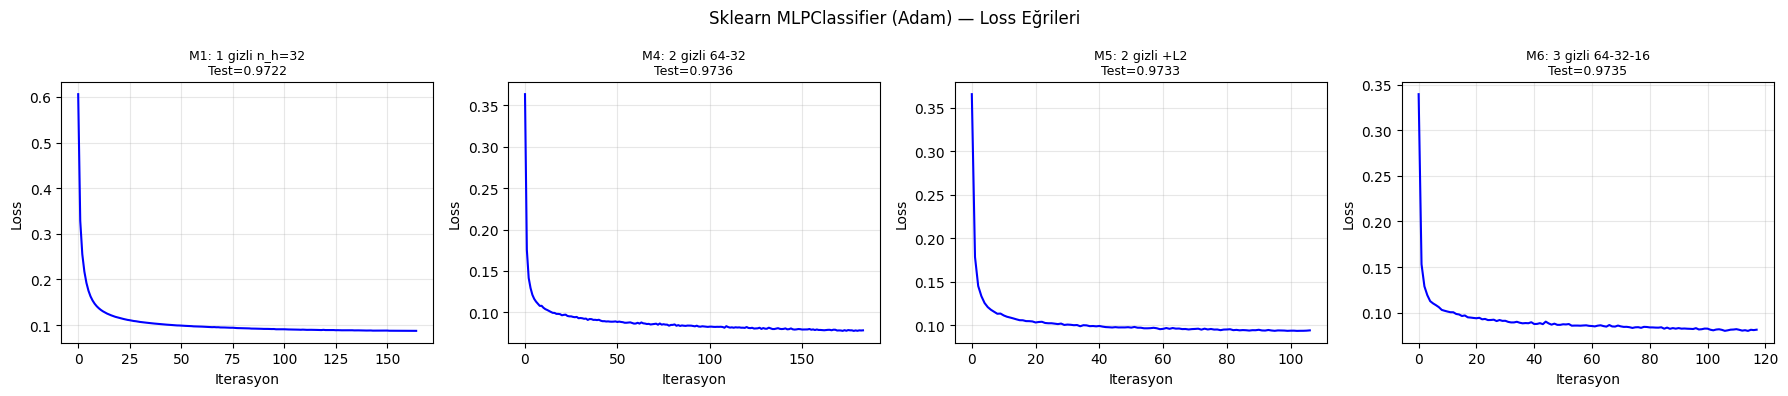

In [17]:
fig, axes = plt.subplots(1, len(results), figsize=(18, 4))

for ax, r in zip(axes, results):
    ax.plot(r['clf'].loss_curve_, 'b-', linewidth=1.5)
    ax.set_title(f"{r['name']}\nTest={r['test']:.4f}", fontsize=9)
    ax.set_xlabel('Iterasyon'); ax.set_ylabel('Loss')
    ax.grid(alpha=0.3)

plt.suptitle('Sklearn MLPClassifier (Adam) — Loss Eğrileri', fontsize=12)
plt.tight_layout(); plt.show()

# **5. Confusion Matrix ve Metrikler**


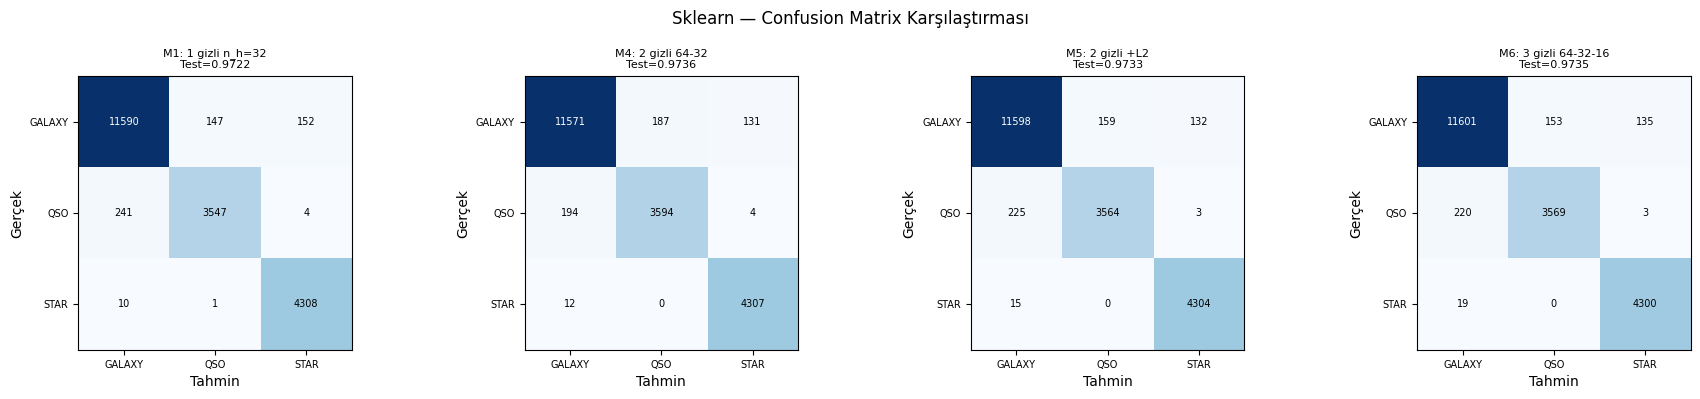

In [18]:
fig, axes = plt.subplots(1, len(results), figsize=(18, 4))

for ax, r in zip(axes, results):
    cm = confusion_matrix(y_test, r['clf'].predict(X_test))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(le.classes_, fontsize=7)
    ax.set_yticklabels(le.classes_, fontsize=7)
    ax.set_title(f"{r['name']}\nTest={r['test']:.4f}", fontsize=8)
    ax.set_xlabel('Tahmin'); ax.set_ylabel('Gerçek')
    for i in range(3):
        for j in range(3):
            ax.text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=7,
                    color='white' if cm[i,j] > cm.max()/2 else 'black')

plt.suptitle('Sklearn — Confusion Matrix Karşılaştırması', fontsize=12)
plt.tight_layout(); plt.show()

In [19]:
# En iyi modelin detaylı metrikleri
print(f"Classification Report — {best['name']}:")
print(classification_report(y_test, best['clf'].predict(X_test), target_names=le.classes_))

Classification Report — M4: 2 gizli 64-32:
              precision    recall  f1-score   support

      GALAXY       0.98      0.97      0.98     11889
         QSO       0.95      0.95      0.95      3792
        STAR       0.97      1.00      0.98      4319

    accuracy                           0.97     20000
   macro avg       0.97      0.97      0.97     20000
weighted avg       0.97      0.97      0.97     20000

